# Google Stock Price Prediction using RNN
This notebook uses a simple Recurrent Neural Network (RNN) model to predict Google stock prices.

In [1]:
# Install required libraries (Run only if needed)
# !pip install tensorflow pandas numpy matplotlib scikit-learn

Signature:
model.fit(
    x=None,
    y=None,
    batch_size=None,
    epochs=1,
    verbose='auto',
    callbacks=None,
    validation_split=0.0,
    validation_data=None,
    shuffle=True,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1,
)
Docstring:
Trains the model for a fixed number of epochs (dataset iterations).

Args:
    x: Input data. It can be:
        - A NumPy array (or array-like), or a list of arrays
        (in case the model has multiple inputs).
        - A backend-native tensor, or a list of tensors
        (in case the model has multiple inputs).
        - A dict mapping input names to the corresponding array/tensors,
        if the model has named inputs.
        - A `keras.utils.PyDataset` returning `(inputs, targets)` or
        `(inputs, targets, sample_weights)`.
        - A `tf.data.Dataset` yielding `(inputs, targets)` or
        `(in

In [3]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [4]:
# Load Dataset

df = pd.read_csv("Google_Stock_Price.csv")

# Remove first two unnecessary rows
df = df.iloc[2:]

# Reset index
df.reset_index(drop=True, inplace=True)

# Convert Close column to numeric
df['Close'] = pd.to_numeric(df['Close'])

print(df.head())

                       Price    Adj Close      Close         High  \
0  2020-01-02 00:00:00+00:00  68.18682098  68.433998  68.43399811   
1  2020-01-03 00:00:00+00:00  67.83010101  68.075996      68.6875   
2  2020-01-06 00:00:00+00:00  69.63805389  69.890503  69.91600037   
3  2020-01-07 00:00:00+00:00  69.50354767  69.755501  70.17500305   
4  2020-01-08 00:00:00+00:00  69.99825287  70.251999  70.59249878   

           Low         Open    Volume  
0  67.32450104  67.42050171  27278000  
1  67.36599731  67.40000153  23408000  
2  67.55000305  67.58149719  46768000  
3  69.57800293  70.02300262  34330000  
4  69.63150024  69.74099731  35314000  


In [5]:
# Use only Close price for prediction

data = df[['Close']].values

# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.10925401]
 [0.10676708]
 [0.11937189]
 [0.11843407]
 [0.12188309]]


In [6]:
# Create Training Data

x_train = []
y_train = []

time_step = 10

for i in range(time_step, len(scaled_data)):
    x_train.append(scaled_data[i-time_step:i, 0])
    y_train.append(scaled_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape for RNN
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (1248, 10, 1)
y_train shape: (1248,)


In [7]:
# Build Simple RNN Model

model = Sequential()

model.add(SimpleRNN(units=50, activation='tanh', input_shape=(x_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

C:\Users\Arclooks\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train Model

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0099
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.7008e-04
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.4976e-04
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.0761e-04
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7046e-04
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7199e-04
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8187e-04
Epoch 10/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8595e-04
Epoch 11/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0040e-04
Epoch 12/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5610e-04
Epoch 13/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2797e-04
Epoch 14/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.7170e-04
Epoch 15/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s

In [9]:
# Predict Prices

predicted = model.predict(x_train)

# Convert back to original values
predicted = scaler.inverse_transform(predicted)

real = scaler.inverse_transform(y_train.reshape(-1, 1))

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


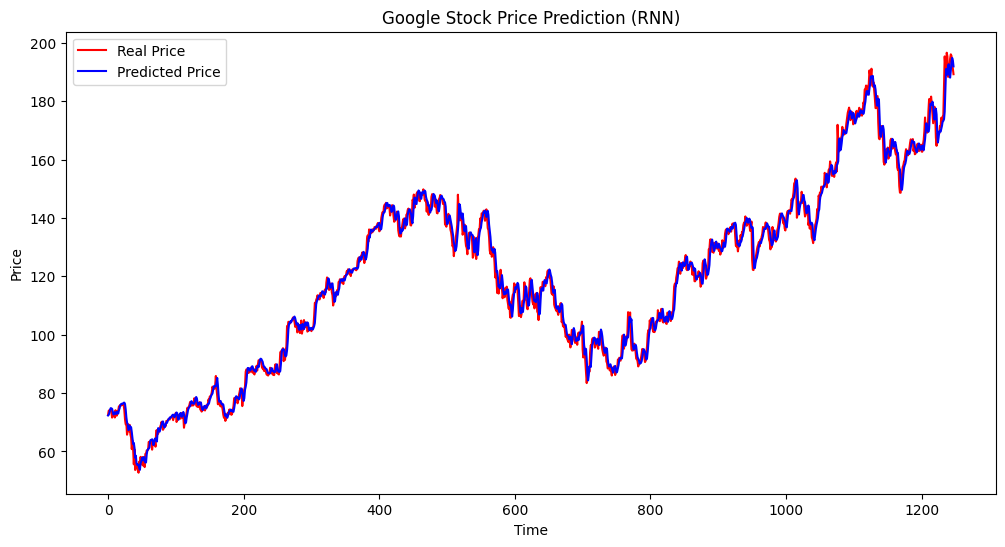

In [10]:
# Plot Results

plt.figure(figsize=(12,6))

plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Conclusion
The RNN model learns patterns from previous Google stock prices and predicts future prices.